In [1]:
import json
import os
from google.colab import drive
import matplotlib.pyplot as plt

drive.mount('/content/drive')

project_data_path = '/content/drive/MyDrive/DSA210-Project/data/'

Mounted at /content/drive


In [6]:
#  Load move_damage_class
with open(os.path.join(project_data_path, 'move_damage_classes.json'), 'r', encoding='utf-8') as f:
    move_data = json.load(f)

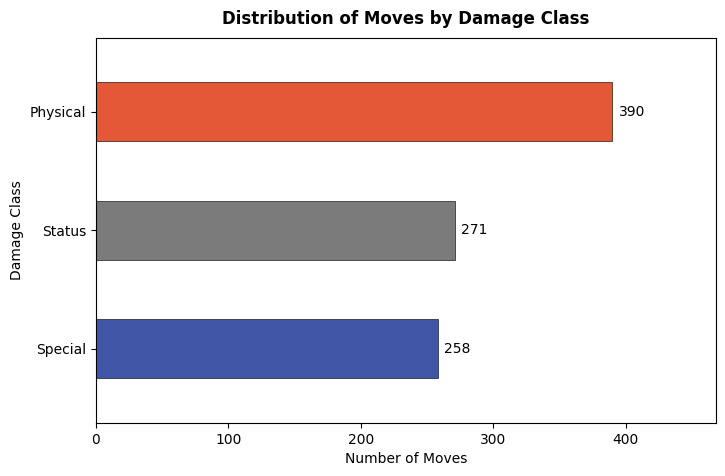

In [7]:
# Move Damage Class Distribution
categories = []
counts = []

for damage_class, moves in move_data.items():
    categories.append(damage_class.capitalize())
    counts.append(len(moves.get('moves', [])))

# Sort the data
sorted_data = sorted(zip(categories, counts), key=lambda x: x[1])
categories, counts = zip(*sorted_data)

# Create Bar Chart
plt.figure(figsize=(8,5))
bars = plt.barh(categories, counts, color=['#213899', '#646464', '#e03a14'], edgecolor='black' ,linewidth=0.5, height=0.5, alpha=0.85)
plt.margins(x=0.2, y=0.15)

# Add labels and title
plt.xlabel('Number of Moves')
plt.ylabel('Damage Class')
plt.title('Distribution of Moves by Damage Class', fontweight='bold', pad=10)

# Add the count numbers next to the bars for clarity
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center')

plt.show()

I was suprised by this as I expected a more balanced distribution between physical and special moves.

In [8]:
#  Load abilities
with open(os.path.join(project_data_path, 'abilities.json'), 'r', encoding='utf-8') as f:
    abilities = json.load(f)

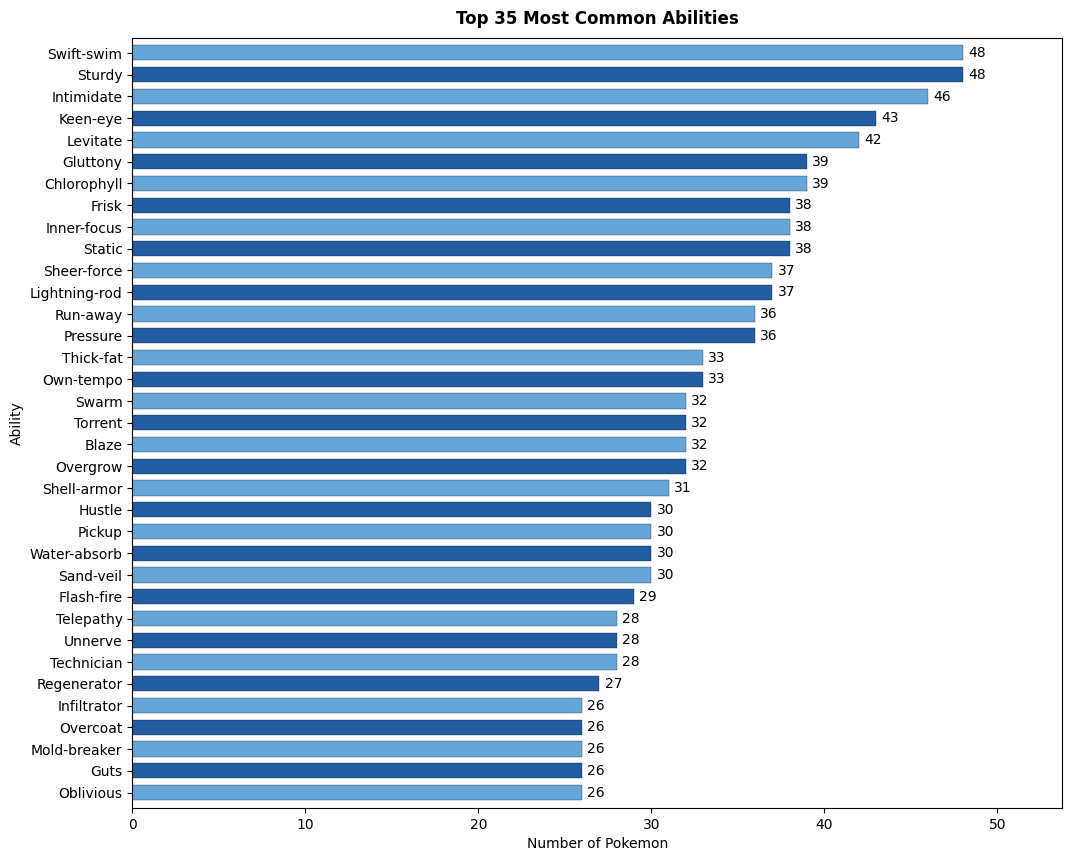

In [9]:
# Top n Most Common Abilities
categories = []
counts = []
# Abilities to display
n = 35

for ability, details in abilities.items():
    categories.append(ability.capitalize())
    counts.append(len(details.get('pokemon', [])))

# Sort the data
sorted_data = sorted(zip(categories, counts), key=lambda x: x[1])
top_n = sorted_data[-n:]
categories, counts = zip(*top_n)

colors = ['#66A5D7', '#235DA1'] * (len(categories) // 2 + 1)
colors = colors[:len(categories)]

# Create Bar Chart
plt.figure(figsize=(12, 10))
bars = plt.barh(categories, counts, color=colors, edgecolor='black', linewidth=0.2, height=0.7)
plt.margins(x=0.12, y=0.01)

# Add labels and title
plt.xlabel('Number of Pokemon')
plt.ylabel('Ability')
plt.title(f'Top {n} Most Common Abilities', fontweight='bold', pad=10)

# Add the count numbers next to the bars for clarity
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center')

# plt.tight_layout()
plt.show()

Now that I am working with Pokémon data I wanted to see which abilities were the most common. My intution was Pressure would be high-up since most early legendary Pokémon have it. I had expected swift swim as it is given to most water types and inner focus which is pretty widely distributed. However I had the impression Intimidate and Sheer Force were rarer, it was suprising to see.

In [10]:
#  Load pokemon and generation jsons
with open(os.path.join(project_data_path, 'pokemon.json'), 'r', encoding='utf-8') as f:
    pokemon = json.load(f)

with open(os.path.join(project_data_path, 'types.json'), 'r', encoding='utf-8') as f:
    types = json.load(f)

In [11]:
types_by_gen = {}
for i in range(9):
  new_entry = {}
  for key in types:
    new_entry[key] = 0
  types_by_gen[i + 1] = new_entry

print(types_by_gen)

{1: {'normal': 0, 'fighting': 0, 'flying': 0, 'poison': 0, 'ground': 0, 'rock': 0, 'bug': 0, 'ghost': 0, 'steel': 0, 'fire': 0, 'water': 0, 'grass': 0, 'electric': 0, 'psychic': 0, 'ice': 0, 'dragon': 0, 'dark': 0, 'fairy': 0}, 2: {'normal': 0, 'fighting': 0, 'flying': 0, 'poison': 0, 'ground': 0, 'rock': 0, 'bug': 0, 'ghost': 0, 'steel': 0, 'fire': 0, 'water': 0, 'grass': 0, 'electric': 0, 'psychic': 0, 'ice': 0, 'dragon': 0, 'dark': 0, 'fairy': 0}, 3: {'normal': 0, 'fighting': 0, 'flying': 0, 'poison': 0, 'ground': 0, 'rock': 0, 'bug': 0, 'ghost': 0, 'steel': 0, 'fire': 0, 'water': 0, 'grass': 0, 'electric': 0, 'psychic': 0, 'ice': 0, 'dragon': 0, 'dark': 0, 'fairy': 0}, 4: {'normal': 0, 'fighting': 0, 'flying': 0, 'poison': 0, 'ground': 0, 'rock': 0, 'bug': 0, 'ghost': 0, 'steel': 0, 'fire': 0, 'water': 0, 'grass': 0, 'electric': 0, 'psychic': 0, 'ice': 0, 'dragon': 0, 'dark': 0, 'fairy': 0}, 5: {'normal': 0, 'fighting': 0, 'flying': 0, 'poison': 0, 'ground': 0, 'rock': 0, 'bug': 0,

In [12]:
types_by_gen = {}
for i in range(9):
  new_entry = {}
  for key in types:
    new_entry[key] = 0
  types_by_gen[i + 1] = new_entry

excluded_forms = ['-mega', '-gmax', '-primal']

for pkmn, details in pokemon.items():
    skip = False
    for keyword in excluded_forms:
      if(keyword in pkmn):
        skip = True
        break
    if(not skip):
      gen_from = details.get('generation')
      past_types = details.get('past_types', [])

      if past_types:
          curr_types = past_types[0]['types']
      else:
          curr_types = details.get('types', [])

      for entry in curr_types:
        types_by_gen[gen_from][entry['type']['name']] += 1

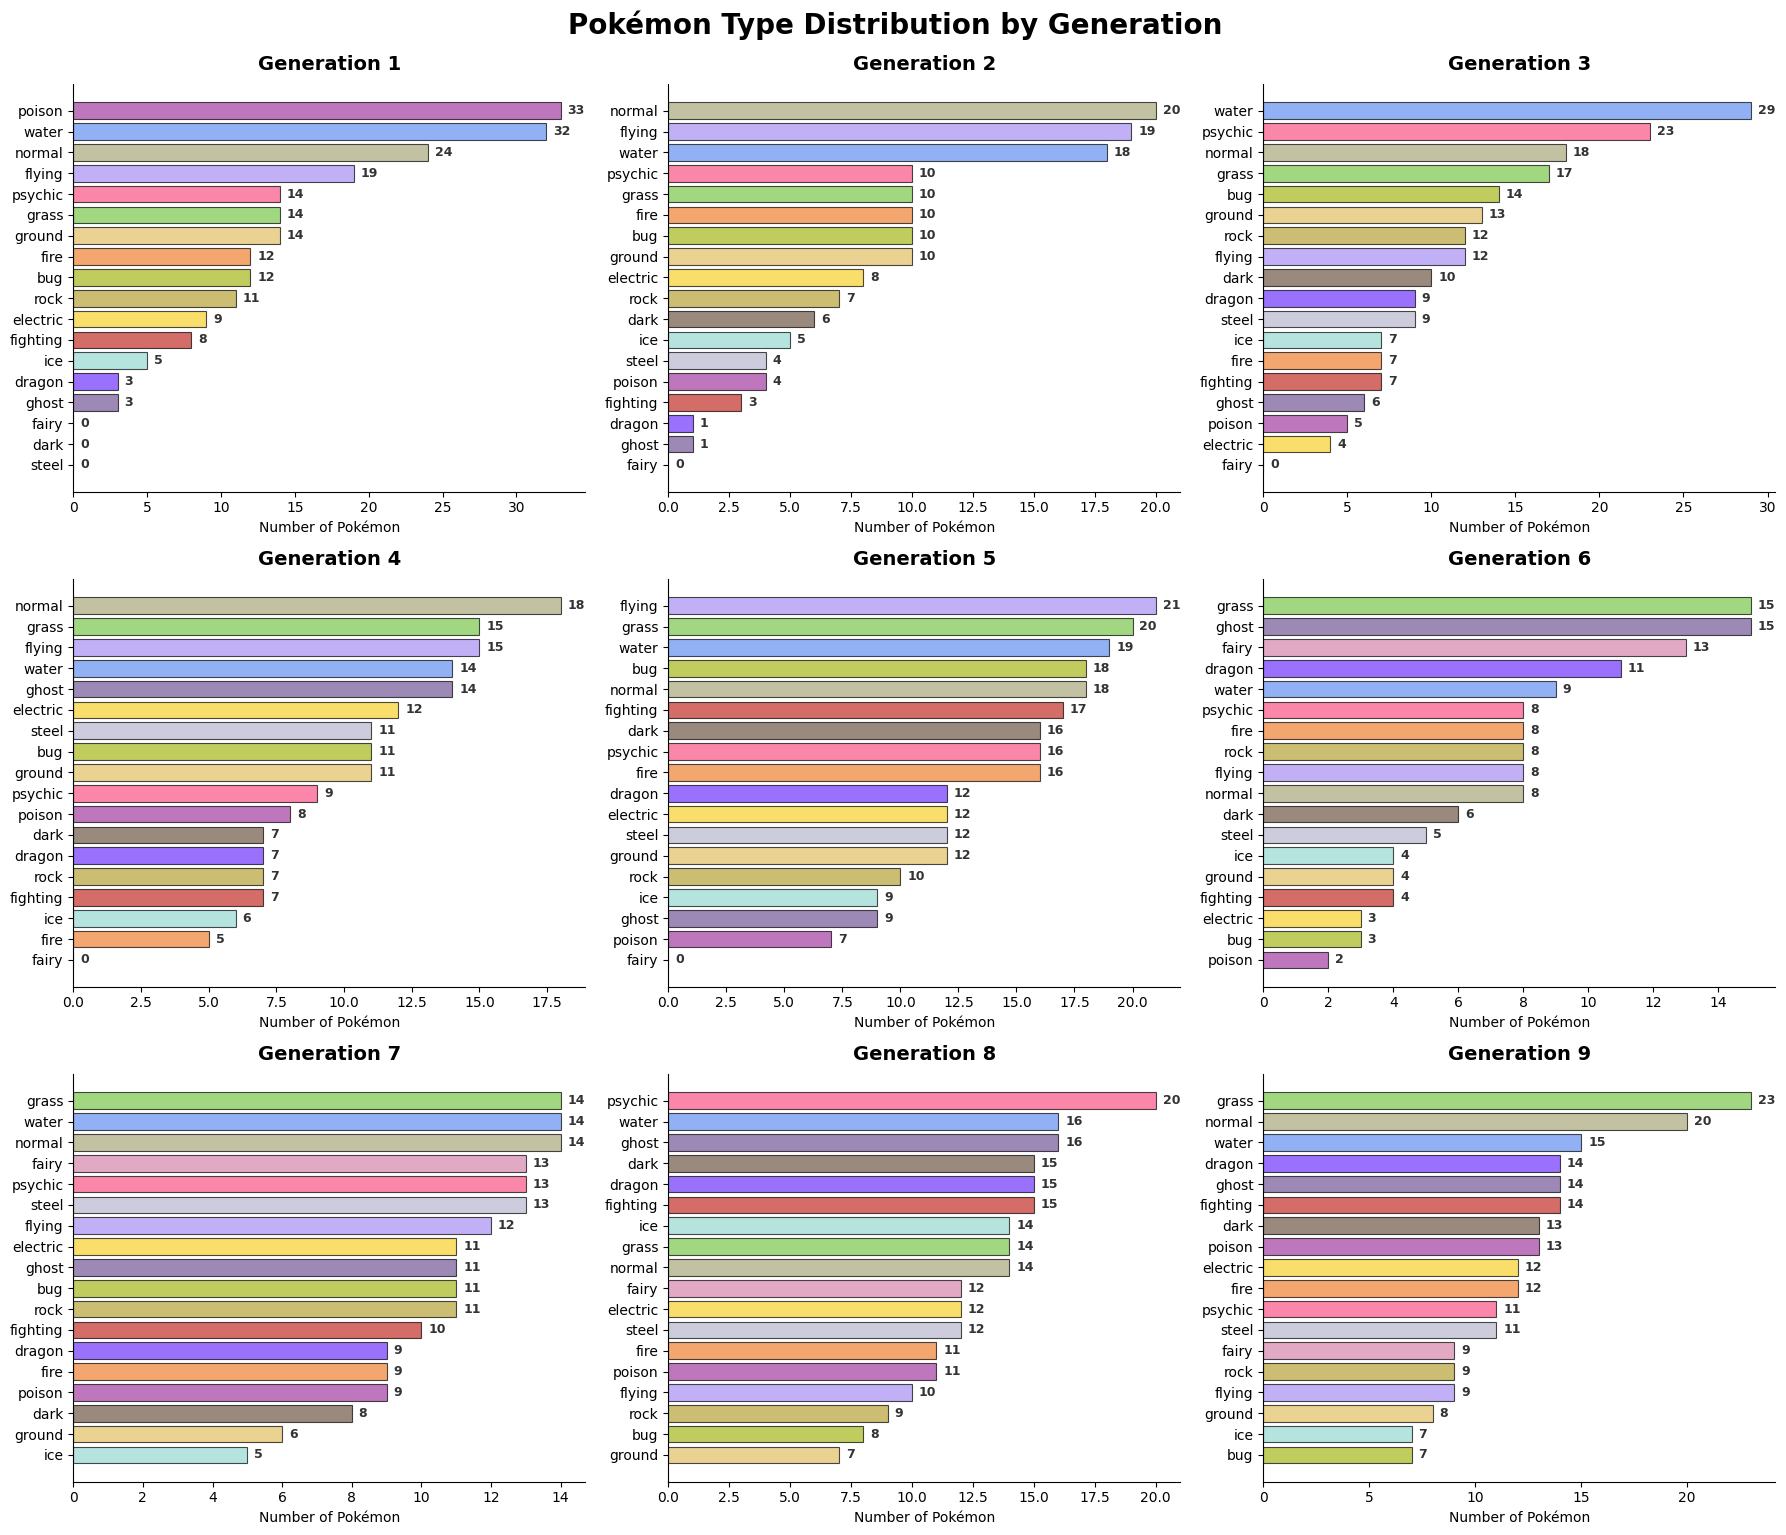

In [13]:
# 1. Standard Hex Colors for Pokemon Types
type_colors = {
    "normal": "#A8A77A", "fire": "#EE8130", "water": "#6390F0", "electric": "#F7D02C",
    "grass": "#7AC74C", "ice": "#96D9D2", "fighting": "#C22E28", "poison": "#A33EA1",
    "ground": "#E2BF65", "flying": "#A98FF3", "psychic": "#F95587", "bug": "#A6B91A",
    "rock": "#B6A136", "ghost": "#735797", "dragon": "#6F35FC", "steel": "#B7B7CE",
    "fairy": "#D685AD", "dark": "#705746"
}

# 2. Setup the figure (3 rows, 3 columns for 9 generations)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()  # Flatten to easily loop 0-8

# 3. Loop through each generation
for i in range(1, 10):
    ax = axes[i-1]
    gen_data = types_by_gen[i]

    # Sort by count (highest at top)
    sorted_types = sorted(gen_data.items(), key=lambda x: x[1])
    labels = [item[0] for item in sorted_types]
    counts = [item[1] for item in sorted_types]
    colors = [type_colors.get(t, '#777777') for t in labels]

    # Create the horizontal bar chart
    bars = ax.barh(labels, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=0.8)
    ax.bar_label(bars, padding=5, fontsize=9, fontweight='bold', color='#333333')

    # Formatting
    ax.set_title(f"Generation {i}", fontsize=14, fontweight='bold', pad=10)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xlabel("Number of Pokémon")

    # Remove top and right spines for a modern look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Final adjustments
plt.tight_layout()
plt.suptitle("Pokémon Type Distribution by Generation", fontsize=20, y=1.02, fontweight='bold')
plt.savefig('type_distribution_by_gen.png', bbox_inches='tight')

One of the questions I had in mind when starting this project was "Are Dragon types actually rare?". Historically Dragon types were rare in Pokémon but in recent generations they were in my opinion becoming common place, the Pokémon community still has this impression that they are rare due to the historic trend. While answering this question I decided to also see the distribution of all types for each generation. As I suspected Dragon types are becoming more common, being in the top half of the graph for generations 6,8 and 9. (Note: The types that have 0 Pokémon in a generation such as Fairy in generations prior to 6 are because those types did not exist back then)

In [14]:
types_by_gen_total = {}
for i in range(9):
  new_entry = {}
  for key in types:
    new_entry[key] = 0
  types_by_gen_total[i + 1] = new_entry

for pkmn, details in pokemon.items():
    gen_from = details.get('generation')
    past_types = details.get('past_types', [])

    if past_types:
        curr_types = past_types[0]['types']
    else:
        curr_types = details.get('types', [])

    for entry in curr_types:
      types_by_gen_total[gen_from][entry['type']['name']] += 1

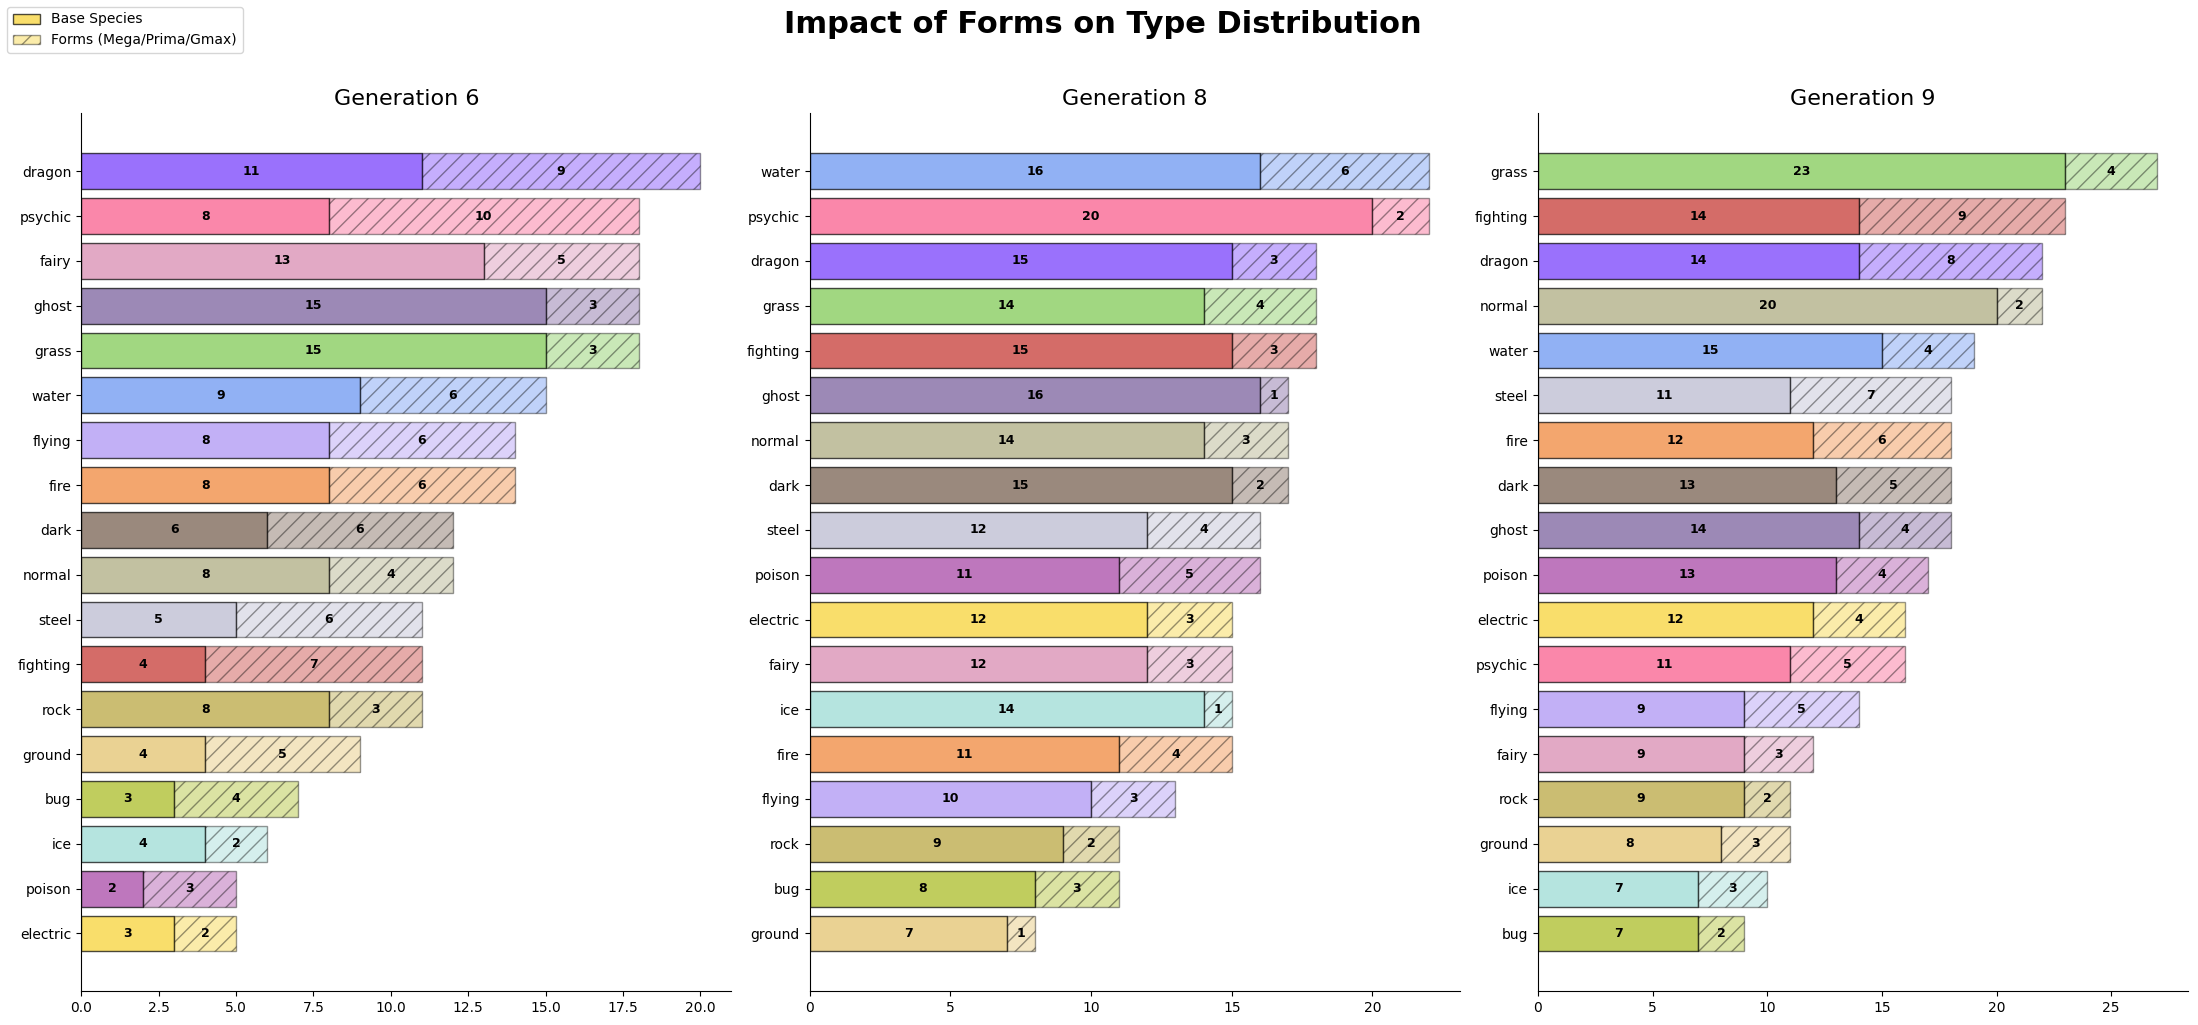

In [15]:
import numpy as np

target_gens = [6, 8, 9]
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

def add_labels(ax, rects, counts, fontsize=9):
    for rect, count in zip(rects, counts):
        if count > 0:
            width = rect.get_width()
            x = rect.get_x() + width / 2
            y = rect.get_y() + rect.get_height() / 2
            ax.text(x, y, str(count), ha='center', va='center',
                    color='black', fontweight='bold', fontsize=fontsize)

for i, gen in enumerate(target_gens):
    ax = axes[i]

    all_types = sorted(type_colors.keys())

    base_counts = [types_by_gen[gen].get(t, 0) for t in all_types]

    extra_counts = [types_by_gen_total[gen].get(t, 0) - types_by_gen[gen].get(t, 0) for t in all_types]

    y_labels = all_types
    b_vals = base_counts
    e_vals = extra_counts

    # Sort by total length
    sort_idx = np.argsort([b + e for b, e in zip(b_vals, e_vals)])
    y_labels = [y_labels[j] for j in sort_idx]
    b_vals = [b_vals[j] for j in sort_idx]
    e_vals = [e_vals[j] for j in sort_idx]

    colors = [type_colors[t] for t in y_labels]
    y_pos = np.arange(len(y_labels))

    # Plot Base
    rects_base = ax.barh(y_pos, b_vals, color=colors, alpha=0.7, edgecolor='black', label='Base Species')

    # Plot Forms
    rects_extra = ax.barh(y_pos, e_vals, left=b_vals, color=colors, alpha=0.4,
            edgecolor='black', hatch='//', label='Forms (Mega/Prima/Gmax)')

    add_labels(ax, rects_base, b_vals)
    add_labels(ax, rects_extra, e_vals)

    # Labels and Titles
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)
    ax.set_title(f"Generation {gen}", fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Formatting
handles, labels = axes[0].get_legend_handles_labels()
plt.suptitle("Impact of Forms on Type Distribution", fontsize=22, fontweight='bold', y=1.02)
fig.legend(labels=labels ,loc='upper left', ncol=1)
plt.tight_layout()

In the previous visualization I had removed mega evolutions, gigantamax forms and primal forms because they would unfairly boost some types for some generations. Mega evolutions only exist in generations 6 and 9, the gigantamax forms are only in generation 8 and primals are in 6. In this graph I wanted to see how much impact the inclusion of this forms would have on the type distribution

In [3]:
#  Load gen9ou data
with open(os.path.join("/content/drive/MyDrive/DSA210-Project/data/raw", 'gen9ou.json'), 'r', encoding='utf-8') as f:
    ou = json.load(f)

In [4]:
def find_key(s):
  s = s.lower().replace(' ','-')
  for pkmn in pokemon:
    if(s in pkmn):
      return pkmn

In [16]:
import pandas as pd

ou_usages = {}

for pkmn in ou.get('pokemon'):
  usage = ou['pokemon'][pkmn]['usage']['weighted']
  gen = pokemon[find_key(pkmn)]['generation']
  ou_usages[pkmn] = [usage, gen]

df = pd.DataFrame.from_dict(ou_usages, orient='index')
df.columns = ['usage', 'generation']
df_clean = df[df['usage'] >= 0.0452]
print(df_clean)

                     usage  generation
Great Tusk          0.3552           9
Kingambit           0.2488           9
Gholdengo           0.2147           9
Dragonite           0.2092           1
Zamazenta           0.1964           8
Iron Valiant        0.1787           9
Ogerpon-Wellspring  0.1785           9
Raging Bolt         0.1570           9
Dragapult           0.1562           8
Ting-Lu             0.1494           9
Kyurem              0.1489           5
Pecharunt           0.1347           9
Hatterene           0.1279           8
Iron Treads         0.1271           9
Slowking-Galar      0.1257           8
Corviknight         0.1208           8
Glimmora            0.1131           9
Cinderace           0.1130           8
Landorus-Therian    0.1125           5
Samurott-Hisui      0.1056           8
Gliscor             0.0963           4
Darkrai             0.0926           4
Alomomola           0.0919           5
Deoxys-Speed        0.0867           3
Iron Moth           0.080

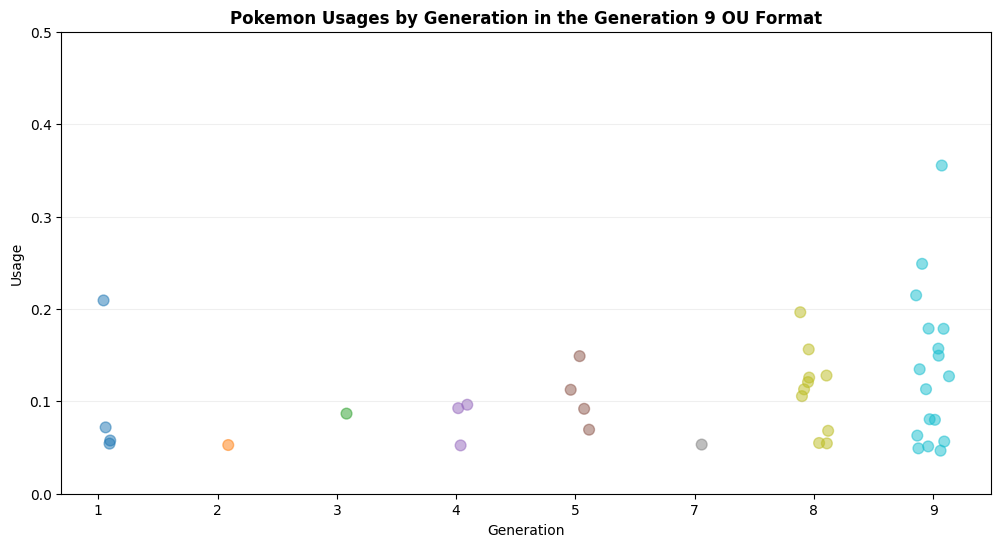

In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Map categories to numerical positions (0, 1, 2...)
# Sort the unique generations to ensure the x-axis is sorted numerically
unique_generations = sorted(df_clean['generation'].unique())
gen_map = {gen: i for i, gen in enumerate(unique_generations)}
x_values = df_clean['generation'].map(gen_map)

# Add 'jitter' (random noise between -0.1 and 0.1)
jitter = np.random.uniform(-0.15, 0.15, size=len(df_clean))

plt.scatter(x_values + jitter, df_clean['usage'],
            c=x_values, cmap='tab10', alpha=0.5, s=60)

# Use the sorted unique_generations for labels to match the sorted x-axis
plt.xticks(ticks=list(gen_map.values()), labels=unique_generations)

plt.ylim(0, 0.5)
plt.ylabel("Usage")
plt.xlabel("Generation")
plt.title("Pokemon Usages by Generation in the Generation 9 OU Format", fontweight='bold')
plt.grid(axis='y', alpha=0.2)
plt.show()

This is the only visualization in this phase that uses data from Smogon API it shows the usage statistics of Pokémon in the OU (OverUsed) format (it is competitive play ruleset) by generation. I had a hunch recent generation Pokémon were more common in this format due to powercreep and this visualization backs up my hunch. The Pokémon with the higher usage in the format are indeed from generations 8 and 9.